# Churn Sample

## Loading libraries and data

In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import nbformat
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [3]:
def load_data(path):
    df = pd.read_csv(path, sep=",")
    df = df.copy()
    return df

In [4]:
path = r"C:\Users\owner\Desktop\churn_prediction\data\Telco_Customer_Churn.csv"
df = load_data(path)

In [5]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

### Understanding the data

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
print(df.columns)
print(df.shape)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')
(7043, 21)


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
# Dropping customer ID
df = df.drop(['customerID'], axis = 1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
# Converting total charges to an integer and checking for null entries
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce') # coerce converts every nonnumerical value that cannot be converted into an integer to NaN
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

checking to see if any other entry in the tenure column is zero

In [11]:
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)
df[df['tenure'] == 0].index

Index([], dtype='int64')

In [12]:
df.fillna(df["TotalCharges"].median())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [13]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
df["SeniorCitizen"]= df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


## Data Preprocessing

Used label encoding to convert the categorical values to numerical values, by assigning a distinct integer to each unique category

In [16]:
def object_to_int(dataframe_series):
    if dataframe_series.dtype=='str':
        dataframe_series = LabelEncoder().fit_transform(dataframe_series)
    return dataframe_series

In [17]:
df = df.apply(lambda x: object_to_int(x))
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


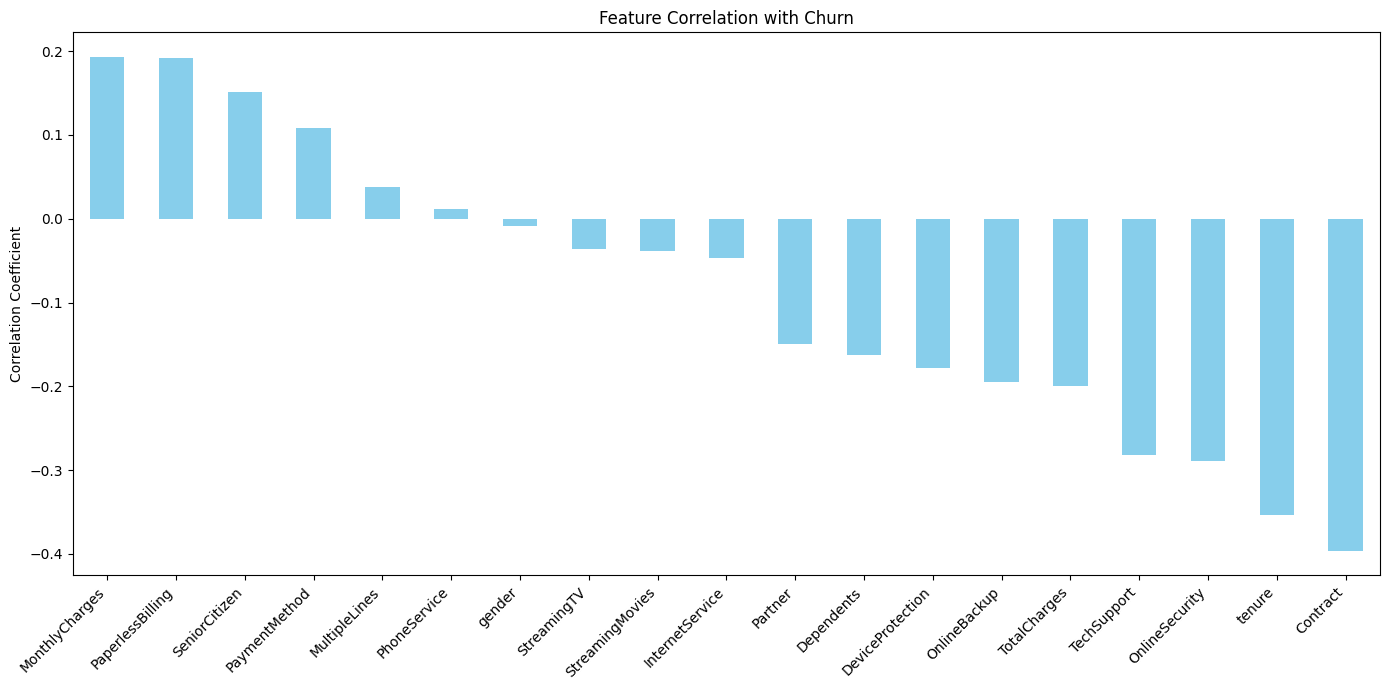

In [18]:
plt.figure(figsize=(14, 7))
# Drop 'Churn' from the correlation array so it doesn't plot a perfect 1.0 correlation with itself
df.corr()['Churn'].drop('Churn').sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Feature Correlation with Churn')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
plt.figure(figsize=(14,7))
df.corr()['Churn'].sort_values(ascending = False)

Churn               1.000000
MonthlyCharges      0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
PaymentMethod       0.107852
MultipleLines       0.038043
PhoneService        0.011691
gender             -0.008545
StreamingTV        -0.036303
StreamingMovies    -0.038802
InternetService    -0.047097
Partner            -0.149982
Dependents         -0.163128
DeviceProtection   -0.177883
OnlineBackup       -0.195290
TotalCharges       -0.199484
TechSupport        -0.282232
OnlineSecurity     -0.289050
tenure             -0.354049
Contract           -0.396150
Name: Churn, dtype: float64

<Figure size 1400x700 with 0 Axes>

In [20]:
# First level split of the data into features and target variable

X = df.drop(columns = ['Churn'])
y = df['Churn'].values

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.30, random_state = 40, stratify=y)

### standardizing numeric attribute

In [22]:
num_cols = ["tenure", 'MonthlyCharges', 'TotalCharges']

In [23]:
scaler= StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## ML Model Learning and Evaluation

### KNN

In [24]:
knn_model = KNeighborsClassifier(n_neighbors = 11) 
knn_model.fit(X_train,y_train)
predicted_y = knn_model.predict(X_test)
accuracy_knn = knn_model.score(X_test,y_test)
print("KNN accuracy:",accuracy_knn)

KNN accuracy: 0.7758293838862559


In [25]:
print(classification_report(y_test, predicted_y))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1549
           1       0.59      0.52      0.55       561

    accuracy                           0.78      2110
   macro avg       0.71      0.69      0.70      2110
weighted avg       0.77      0.78      0.77      2110



### SVC

In [26]:
svc_model = SVC(random_state = 1)
svc_model.fit(X_train,y_train)
predict_y = svc_model.predict(X_test)
accuracy_svc = svc_model.score(X_test,y_test)
print("SVM accuracy is :",accuracy_svc)

SVM accuracy is : 0.8075829383886256


In [27]:
print(classification_report(y_test, predict_y))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1549
           1       0.69      0.50      0.58       561

    accuracy                           0.81      2110
   macro avg       0.76      0.71      0.73      2110
weighted avg       0.80      0.81      0.80      2110



In [28]:
model_rf = RandomForestClassifier(n_estimators=500 , oob_score = True, n_jobs = -1,
                                  random_state =50, max_features = "log2",
                                  max_leaf_nodes = 30)
model_rf.fit(X_train, y_train)

# Make predictions
prediction_test = model_rf.predict(X_test)
print (metrics.accuracy_score(y_test, prediction_test))

0.8137440758293839


In [29]:
print(classification_report(y_test, prediction_test))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1549
           1       0.71      0.51      0.59       561

    accuracy                           0.81      2110
   macro avg       0.77      0.72      0.74      2110
weighted avg       0.80      0.81      0.80      2110



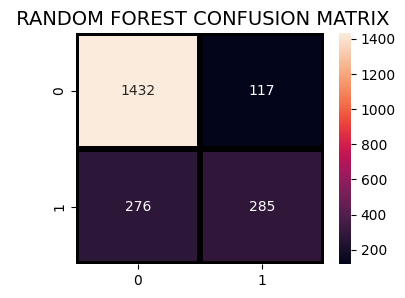

In [30]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, prediction_test),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title(" RANDOM FOREST CONFUSION MATRIX",fontsize=14)
plt.show()

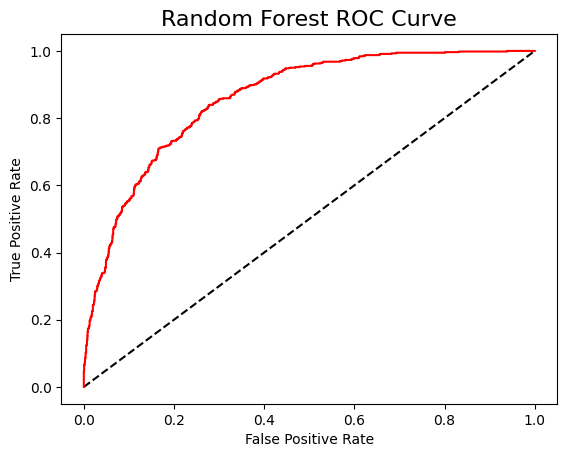

In [31]:
y_rfpred_prob = model_rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, thresholds = roc_curve(y_test, y_rfpred_prob)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr_rf, tpr_rf, label='Random Forest',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve',fontsize=16)
plt.show()

### Logistic Regression

In [32]:
lr_model = LogisticRegression()
lr_model.fit(X_train,y_train)
accuracy_lr = lr_model.score(X_test,y_test)
print("Logistic Regression accuracy is :",accuracy_lr)

Logistic Regression accuracy is : 0.8090047393364929


In [33]:
lr_pred= lr_model.predict(X_test)
report = classification_report(y_test,lr_pred)
print(report)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1549
           1       0.66      0.58      0.62       561

    accuracy                           0.81      2110
   macro avg       0.76      0.74      0.75      2110
weighted avg       0.80      0.81      0.80      2110



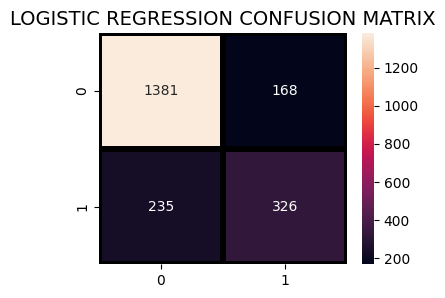

In [34]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, lr_pred),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title("LOGISTIC REGRESSION CONFUSION MATRIX",fontsize=14)
plt.show()

In [35]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train,y_train)
predictdt_y = dt_model.predict(X_test)
accuracy_dt = dt_model.score(X_test,y_test)
print("Decision Tree accuracy is :",accuracy_dt)

Decision Tree accuracy is : 0.7298578199052133


In [36]:
print(classification_report(y_test, predictdt_y))

              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1549
           1       0.49      0.52      0.51       561

    accuracy                           0.73      2110
   macro avg       0.66      0.66      0.66      2110
weighted avg       0.74      0.73      0.73      2110



### Ada Boost Classifier

In [37]:
a_model = AdaBoostClassifier()
a_model.fit(X_train,y_train)
a_preds = a_model.predict(X_test)
print("AdaBoost Classifier accuracy")
metrics.accuracy_score(y_test, a_preds)

AdaBoost Classifier accuracy


0.8127962085308057

In [38]:
print(classification_report(y_test, a_preds))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1549
           1       0.68      0.56      0.62       561

    accuracy                           0.81      2110
   macro avg       0.76      0.73      0.75      2110
weighted avg       0.81      0.81      0.81      2110



In [39]:
models = {
    "LogisticRegression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    'AdaBoostClassifier': AdaBoostClassifier(),
    "Naive Bayes": GaussianNB()
}

Training LogisticRegression...
LogisticRegression Recall: 0.581 | Accuracy: 0.809


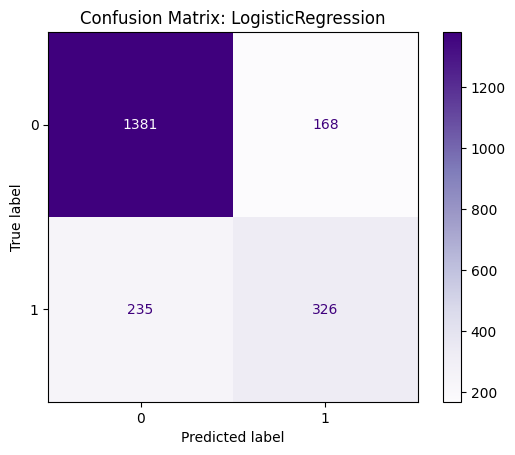

Training Random Forest...
Random Forest Recall: 0.510 | Accuracy: 0.791


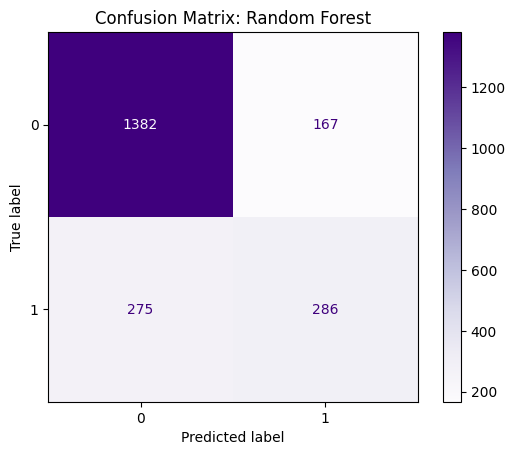

Training AdaBoostClassifier...
AdaBoostClassifier Recall: 0.563 | Accuracy: 0.813


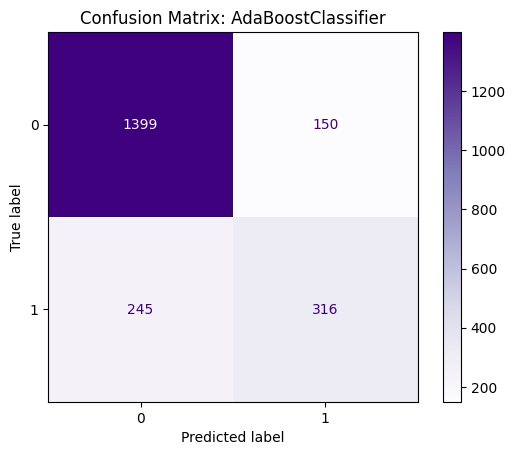

Training Naive Bayes...
Naive Bayes Recall: 0.768 | Accuracy: 0.764


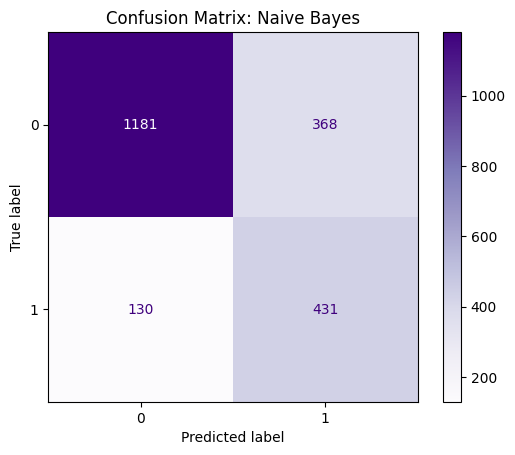

,Model,Recall,Accuracy
0,Naive Bayes,0.768271,0.763981
1,LogisticRegression,0.581105,0.809005
2,AdaBoostClassifier,0.563280,0.812796
3,Random Forest,0.509804,0.790521


In [40]:
# Initializing a dictionary to store the models
results = {}

results = {
    'Model': [],
    'Recall': [],
    'Accuracy': []
}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    recall = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    results['Model'].append(model_name)
    results['Recall'].append(recall)
    results['Accuracy'].append(accuracy)
    
    print(f"{model_name} Recall: {recall:.3f} | Accuracy: {accuracy:.3f}")

    #Adding confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    #Plotting with model name as title
    disp.plot(cmap='Purples')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

result_df = pd.DataFrame(results)
result_df = result_df.sort_values(by="Recall", ascending=False).reset_index(drop=True)
result_df

### Observation
The model with the best performance is Naive Bayes, with the following parameters <BR>
TN: 1181<BR>
TP: 431 (the huge gap between TN and TP indicates a class imbalance)<br>
FP: 368 (Type I error) <br>
FN: 130 (Type II error)<br>
Type II error is the most important parameter for this model, as the cost of wrong classify a customer that is likely to churn is high.

### Voting Classifer

In [41]:
from sklearn.ensemble import VotingClassifier

clf1 = LogisticRegression()
clf2 = RandomForestClassifier(n_estimators=500 , oob_score = True, n_jobs = -1, random_state =50, max_features = "log2", max_leaf_nodes = 30)
clf3 = AdaBoostClassifier()
clf4 = GaussianNB()

labels = ['Logistic Regression', 'Random Forest', 'AdaBoost', 'Naive Bayes']
voting_clf = VotingClassifier(estimators=[('lr', clf1), ('rf', clf2), ('ab', clf3), ('nb', clf4)], voting='soft')
voting_clf.fit(X_train, y_train)
predictions = voting_clf.predict(X_test)
print("Voting Classifier Recall:", recall_score(y_test, predictions))
print(classification_report(y_test, predictions))

Voting Classifier Recall: 0.6862745098039216
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1549
           1       0.59      0.69      0.64       561

    accuracy                           0.79      2110
   macro avg       0.74      0.76      0.75      2110
weighted avg       0.80      0.79      0.80      2110



Recall is the most important metrics as a high FN is more costly. Currently, NaiveBayes has the highest Recall with 0.786. I will be doing some feature selection and balancing the dataset

## Fixing Class Imbalance

### Random Oversampling
randomly duplicates existing examples from the minority class

In [42]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

In [43]:
# Initializing a dictionary to store the models
results = {}

results = {
    'Model': [],
    'Recall': [],
    'Accuracy': []
}

for model_name, model in models.items():
    print(f'Training {model_name}...')
    model.fit(X_train_ros, y_train_ros)
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    recall = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Append to results dictionary
    results['Model'].append(model_name)
    results['Recall'].append(recall)
    results['Accuracy'].append(accuracy)
    
    print(f'{model_name} Recall: {recall:.3f} | Accuracy: {accuracy:.3f}')
    
    # # Adding confusion matrix
    # cm = confusion_matrix(y_test, y_pred)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    # # Plotting with model name as title
    # disp.plot(cmap='Blues')
    # plt.title(f'Confusion Matrix After Oversampling: {model_name}')
    # plt.show()

# Create DataFrame and sort
result_df = pd.DataFrame(results)
result_df = result_df.sort_values(by='Recall', ascending=False).reset_index(drop=True)

print("\nOversampling Results:")
result_df

Training LogisticRegression...
LogisticRegression Recall: 0.820 | Accuracy: 0.750
Training Random Forest...
Random Forest Recall: 0.619 | Accuracy: 0.776
Training AdaBoostClassifier...
AdaBoostClassifier Recall: 0.825 | Accuracy: 0.744
Training Naive Bayes...
Naive Bayes Recall: 0.820 | Accuracy: 0.742

Oversampling Results:


,Model,Recall,Accuracy
0,AdaBoostClassifier,0.825312,0.744076
1,LogisticRegression,0.819964,0.750237
2,Naive Bayes,0.819964,0.741706
3,Random Forest,0.618538,0.775829


In [44]:
ada_model_ros = AdaBoostClassifier()
ada_model_ros.fit(X_train_ros, y_train_ros)
ada_ros_pred = ada_model_ros.predict(X_test)
print("AdaBoost Classifier Recall after oversampling:", recall_score(y_test, ada_ros_pred))

AdaBoost Classifier Recall after oversampling: 0.8253119429590018


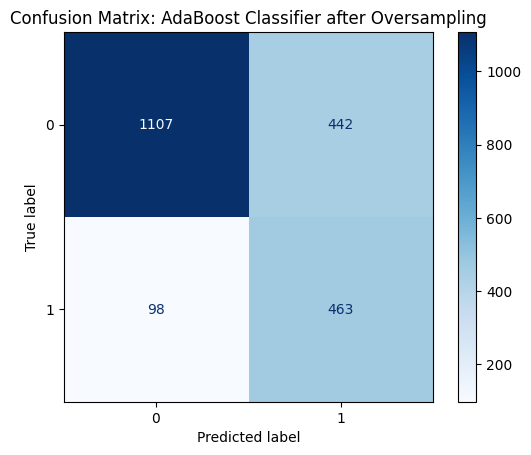

In [45]:
cm= confusion_matrix(y_test, ada_ros_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix: AdaBoost Classifier after Oversampling")
plt.show()

### Random Undersampling
removes existing samples from the majority class dataset

In [46]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

In [47]:
# Initializing a dictionary to store the models
results = {}

results = {
    'Model': [],
    'Recall': [],
    'Accuracy': []
}

for model_name, model in models.items():
    print(f'Training {model_name}...')
    model.fit(X_train_rus, y_train_rus)
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    recall = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Append to results dictionary
    results['Model'].append(model_name)
    results['Recall'].append(recall)
    results['Accuracy'].append(accuracy)
    
    print(f'{model_name} Recall: {recall:.3f} | Accuracy: {accuracy:.3f}')
    
    # # Adding confusion matrix
    # cm = confusion_matrix(y_test, y_pred)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    # # Plotting with model name as title
    # disp.plot(cmap='Reds')
    # plt.title(f'Confusion Matrix after Undersampling: {model_name}')
    # plt.show()

# Create DataFrame and sort
result_df = pd.DataFrame(results)
result_df = result_df.sort_values(by='Recall', ascending=False).reset_index(drop=True)
print("\nUndersampling Results:")
result_df

Training LogisticRegression...
LogisticRegression Recall: 0.824 | Accuracy: 0.748
Training Random Forest...
Random Forest Recall: 0.795 | Accuracy: 0.743
Training AdaBoostClassifier...
AdaBoostClassifier Recall: 0.824 | Accuracy: 0.742
Training Naive Bayes...
Naive Bayes Recall: 0.818 | Accuracy: 0.733

Undersampling Results:


,Model,Recall,Accuracy
0,LogisticRegression,0.823529,0.748341
1,AdaBoostClassifier,0.823529,0.742180
2,Naive Bayes,0.818182,0.732701
3,Random Forest,0.795009,0.743128


In [48]:
log_rus_model = LogisticRegression()
log_rus_model.fit(X_train_rus, y_train_rus)
log_rus_pred = log_rus_model.predict(X_test)
print("Logistic Regression Recall after undersampling:", recall_score(y_test, log_rus_pred  ))  

Logistic Regression Recall after undersampling: 0.8235294117647058


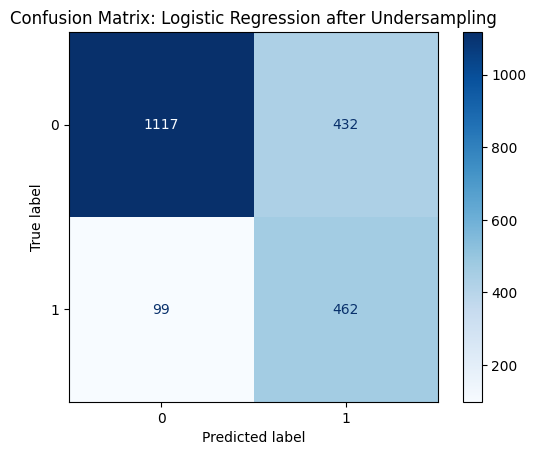

In [49]:
cm= confusion_matrix(y_test, log_rus_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
#Plotting with model name as title
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix: Logistic Regression after Undersampling")
plt.show()

### Evaluating resampled models using ROC

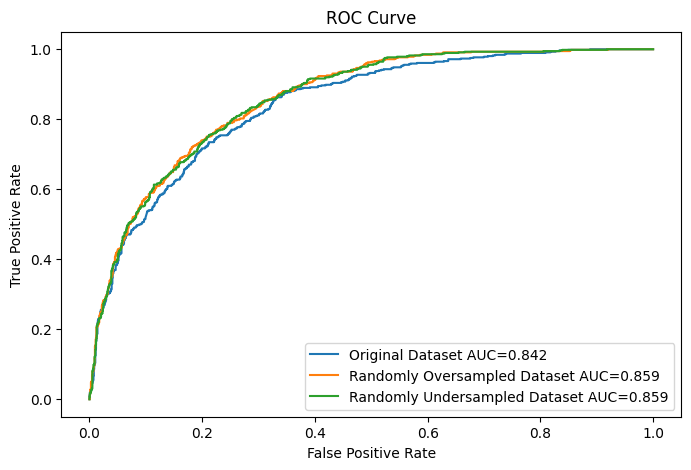

In [50]:
from sklearn.svm import SVC
from sklearn import metrics
import matplotlib.pyplot as plt

# Helper function for plotting ROC
def plot_roc(ax, X_train, y_train, X_test, y_test, title):
    clf = SVC(kernel='linear',probability=True)
    clf.fit(X_train, y_train)
    y_test_pred = clf.predict_proba(X_test)[:,1]
    fpr, tpr, thresh = metrics.roc_curve(y_test, y_test_pred)
    auc = metrics.roc_auc_score(y_test, y_test_pred)
    ax.plot(fpr,tpr,label=f"{title} AUC={auc:.3f}")

    ax.set_title('ROC Curve')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc=0)

# Plot all ROC into one graph
fig,ax = plt.subplots(1,1,figsize=(8,5))
plot_roc(ax, X_train, y_train, X_test, y_test, 'Original Dataset')
plot_roc(ax, X_train_ros, y_train_ros, X_test, y_test, 'Randomly Oversampled Dataset')
plot_roc(ax, X_train_rus, y_train_rus, X_test, y_test, 'Randomly Undersampled Dataset')

Currently, model's performance only improved slightly after oversampling and undersampling, will consider using SMOTE tomorrow and also research other means of fixing imbalanced dataset. Although the currently recall is management and might be improved after Hyperparameter finetuning.

Steps for tomoroww <br>
Try SMOTE and other methods of fixing imbalanced dataset<br>
Do a bivariate and trivariate analysis, to understand correlation and drop low signal features<br>
Do some feature selection and feature creation if possible<br>
Hyperparameter finetuning<br>

### Oversampling with SMOTE

In [51]:
from imblearn.over_sampling import SMOTE
from sklearn.svm import LinearSVC

# Perform random sampling
smote = SMOTE(random_state=0)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [52]:
ada_smote_model = AdaBoostClassifier()
ada_smote_model.fit(X_train_smote, y_train_smote)
ada_smote_pred = ada_smote_model.predict(X_test)
print("AdaBoost Classifier Recall after SMOTE:", recall_score(y_test, ada_smote_pred))


AdaBoost Classifier Recall after SMOTE: 0.8288770053475936


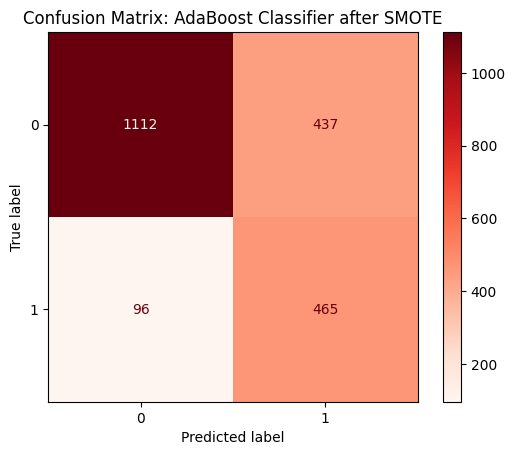

In [53]:
cm = confusion_matrix(y_test, ada_smote_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')
plt.title(f"Confusion Matrix: AdaBoost Classifier after SMOTE")
plt.show()